# BioSED: Notebook 4 - Evaluación del Desempeño y Generalización del Modelo

## 1. Introducción y Objetivos de la Fase de Evaluación

En esta etapa abordamos la **Evaluación Cuantitativa y Diagnóstica** del modelo de Detección de Eventos Sonoros Bioacústicos (BioSED) [5]. El objetivo es auditar de forma rigurosa la capacidad de generalización de la Red Convolucional Recurrente (CRNN) sobre el conjunto de prueba independiente (`test_split.csv`), el cual ha permanecido completamente aislado y libre de fuga de información durante las iteraciones de optimización del bucle de entrenamiento [5].

La evaluación estadística de un detector acústico frame-a-frame exige ir más allá de las métricas de clasificación global por archivo. Utilizaremos herramientas de la teoría de detección de señales y del aprendizaje estadístico para caracterizar de forma fina el comportamiento de las predicciones frente a la resolución temporal del pseudo-ground-truth [5].

Los objetivos específicos de este notebook son:
1.  **Auditoría de Consistencia**: Implementar validaciones que confirmen la presencia física de los pesos unificados del modelo (`biosed_crnn_checkpoint.pth`) y del subconjunto de prueba unificado [5].
2.  **Evaluación de Precisión-Recall**: Calcular de forma exacta el *Average Precision* (AP) por especie y el mAP global sobre los frames de prueba para cuantificar la calidad de la red [5].
3.  **Análisis Paramétrico del Umbral**: Estudiar la variación de las métricas de clasificación (Precisión, Exhaustividad y F1) en función del umbral de decisión para proponer el valor de corte óptimo para el despliegue del frontend interactivo [5].
4.  **Diagnóstico de Firmas Acústicas**: Analizar cuáles especies presentan el mayor y menor desempeño, correlacionándolo con las características físicas de sus cantos e identificando de forma visual casos de éxito y de error temporal [5].

## 2. Configuración General del Entorno y Carga de Dependencias

Para garantizar que el notebook de evaluación sea completamente independiente, inicializaremos las dependencias necesarias de PyTorch para el manejo del modelo (`torch`, `nn`), manipulación de datos tabulares (`pandas`, `numpy`), visualización científica (`matplotlib`, `seaborn`), análisis de señales de audio (`librosa`) y cálculo de métricas de generalización (`scikit-learn`, importando de forma explícita `average_precision_score` y `precision_recall_curve`) [5].

Configuraremos las rutas de acceso de evaluación del proyecto, las cuales apuntan de forma directa hacia el directorio de datos (`../dataset_aves`) y hacia los artefactos unificados de salida (`../artifacts`), tales como el archivo del split de prueba (`test_split.csv`) y los pesos entrenados de la red (`biosed_crnn_checkpoint.pth`) [5]. Asimismo, definiremos la arquitectura de la red `CRNN_BioSED` para que el notebook pueda instanciar el modelo de forma local y cargar sus pesos sinápticos [5].

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import torchaudio
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, precision_recall_curve

# Desactivar advertencias de deprecación estéticas de las librerías de audio y visualización
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuración estética global para visualizaciones de curvas precisión-recall y matrices de confusión
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Definición de rutas relativas de evaluación (subiendo un nivel desde la carpeta notebooks/)
BASE_DIR = "../dataset_aves"
METADATA_PATH = os.path.join(BASE_DIR, "df_metadata_audios.csv")
LABELS_PATH = os.path.join(BASE_DIR, "df_etiquetas_fuertes.csv")
ARTIFACTS_DIR = "../artifacts"
CHECKPOINT_PATH = os.path.join(ARTIFACTS_DIR, "biosed_crnn_checkpoint.pth")
TEST_SPLIT_PATH = os.path.join(ARTIFACTS_DIR, "splits", "test_split.csv")

# Detectar el hardware activo para la inferencia de prueba (prioriza CUDA si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Entorno de evaluación unificado:")
print(f"  - Dispositivo de cómputo activo para inferencia: {device}")
print(f"  - Ruta del Checkpoint oficial a evaluar:       {os.path.abspath(CHECKPOINT_PATH)}")
print(f"  - Ruta del split de prueba (test_split.csv):   {os.path.abspath(TEST_SPLIT_PATH)}")


# Definición de la arquitectura exacta de la red (Requerido para instanciar el modelo y cargar los pesos)
class CRNN_BioSED(nn.Module):
    def __init__(self, num_classes=10):
        super(CRNN_BioSED, self).__init__()
        
        # 1. Bloque Convolucional 2D: Extractor de características visuales-espectrales
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)), # Reduce frecuencias (64 -> 32), mantiene temporal
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)), # Reduce frecuencias (32 -> 16), mantiene temporal
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2))  # Reduce frecuencias (16 -> 8), mantiene temporal
        )
        
        # 2. Capa Recurrente Bidireccional (BiGRU): Modelador de dependencias de secuencia temporal
        self.gru = nn.GRU(
            input_size=128 * 8, 
            hidden_size=128, 
            num_layers=2,
            batch_first=True, 
            bidirectional=True, 
            dropout=0.2
        )
        
        # 3. Capa Lineal Clasificadora y Activación Sigmoide
        self.fc = nn.Linear(in_features=128 * 2, out_features=num_classes)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x shape: [Batch, Canal=1, Frames, Mels]
        x = self.conv_block(x)
        batch, c, frames, m = x.shape
        x = x.permute(0, 2, 1, 3)
        x = x.reshape(batch, frames, c * m)
        x, _ = self.gru(x)
        x = self.fc(x)
        y_prob = self.sigmoid(x)
        return y_prob

Entorno de evaluación unificado:
  - Dispositivo de cómputo activo para inferencia: cuda
  - Ruta del Checkpoint oficial a evaluar:       /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/biosed_crnn_checkpoint.pth
  - Ruta del split de prueba (test_split.csv):   /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/splits/test_split.csv


## 3. Auditoría de Consistencia y Control de Calidad del Entorno

### 3.1. Verificación Programática de Entradas de Evaluación

Antes de instanciar los cargadores de datos de prueba o realizar la inferencia con el modelo de aprendizaje profundo, implementaremos una **etapa de auditoría automatizada**. Esto certifica de forma inequívoca la presencia física del archivo de pesos oficiales unificado (`biosed_crnn_checkpoint.pth`), del archivo descriptor del subconjunto de prueba (`test_split.csv`) y de los índices tabulares del dataset de la Fase 1 [5].

Si esta verificación programática detecta alguna ausencia o inconsistencia física, detendrá el flujo y desplegará instrucciones detalladas para restaurar el entorno, previniendo errores numéricos o excepciones inesperadas durante la etapa de generalización [5].

In [2]:
import os
import pandas as pd

# Lista para registrar las inconsistencias detectadas en la fase de evaluación
inconsistencias_eval = []

print("=== INICIANDO CONTROL DE CALIDAD PARA LA EVALUACIÓN ===")

# 1. Verificar existencia física e integridad del checkpoint de pesos unificado
if os.path.exists(CHECKPOINT_PATH):
    # Intentar cargar los metadatos básicos del checkpoint para confirmar que no esté corrupto
    try:
        ckpt_meta = torch.load(CHECKPOINT_PATH, map_location="cpu")
        print(f"  [OK] biosed_crnn_checkpoint.pth presente. Clases empaquetadas: {len(ckpt_meta['clases'])}")
    except Exception as e:
        inconsistencias_eval.append(f"El archivo del checkpoint está dañado o corrupto. Detalle: {e}")
else:
    inconsistencias_eval.append(f"Falta el checkpoint oficial en la ruta: {CHECKPOINT_PATH}")

# 2. Verificar existencia física del archivo de la partición de prueba (test_split)
if os.path.exists(TEST_SPLIT_PATH):
    df_test_split = pd.read_csv(TEST_SPLIT_PATH)
    if len(df_test_split) > 0:
        print(f"  [OK] test_split.csv presente. Archivos de audio asignados a prueba: {len(df_test_split)}")
    else:
        inconsistencias_eval.append("El archivo test_split.csv está vacío en disco.")
else:
    inconsistencias_eval.append(f"Falta la partición de prueba en la ruta: {TEST_SPLIT_PATH}")

# 3. Verificar archivos base del dataset de la Fase 1
if os.path.exists(METADATA_PATH):
    print(f"  [OK] df_metadata_audios.csv presente.")
else:
    inconsistencias_eval.append(f"Falta df_metadata_audios.csv en la ruta: {METADATA_PATH}")

if os.path.exists(LABELS_PATH):
    print(f"  [OK] df_etiquetas_fuertes.csv presente.")
else:
    inconsistencias_eval.append(f"Falta df_etiquetas_fuertes.csv en la ruta: {LABELS_PATH}")

# 4. Emitir veredicto final e instrucciones de mitigación si falla
print("\n=== VEREDICTO DE LA AUDITORÍA ===")
if len(inconsistencias_eval) == 0:
    print("ESTADO: ENTORNO CONSISTENTE. Puedes proceder de forma segura con la evaluación de generalización.")
else:
    print("ESTADO: ENTORNO INCONSISTENTE. No se puede iniciar la evaluación.")
    print("\n--------------------------------------------------------------------------------")
    print("                       INSTRUCCIONES DE RECUPERACIÓN                            ")
    print("--------------------------------------------------------------------------------")
    print("Se detectaron los siguientes errores en tu entorno:")
    for err in inconsistencias_eval:
        print(f"  * [FALTA] {err}")
    print("\nACCIÓN REQUERIDA:")
    print("  1. Si falta el dataset o las etiquetas, ejecuta el Notebook '01_dataset_y_etiquetado.ipynb'.")
    print("  2. Si falta el split de prueba o el checkpoint, ejecuta el Notebook '03_entrenamiento_CRNN_BioSED.ipynb'.")
    print("  3. Una vez solucionado, vuelve a correr esta celda de verificación.")
    print("--------------------------------------------------------------------------------\n")
    raise AssertionError("El entorno local no cuenta con los artefactos necesarios para la evaluación.")

=== INICIANDO CONTROL DE CALIDAD PARA LA EVALUACIÓN ===
  [OK] biosed_crnn_checkpoint.pth presente. Clases empaquetadas: 10
  [OK] test_split.csv presente. Archivos de audio asignados a prueba: 113
  [OK] df_metadata_audios.csv presente.
  [OK] df_etiquetas_fuertes.csv presente.

=== VEREDICTO DE LA AUDITORÍA ===
ESTADO: ENTORNO CONSISTENTE. Puedes proceder de forma segura con la evaluación de generalización.


### 3.2. Protocolo de Reconstrucción de Particiones y Trazabilidad

Para garantizar la honestidad estadística de la evaluación, es una regla inflexible que las métricas de generalización se calculen de forma exclusiva sobre los archivos de audio registrados en el subconjunto de prueba (`test_split.csv`), los cuales han permanecido invisibles para el modelo durante la optimización de los pesos [5].

En caso de que este archivo descriptor de particiones se pierda o sea borrado accidentalmente del disco físico:
1.  **Garantía de Semilla**: La división se puede reconstruir de forma exacta y determinista ejecutando la celda de partición en el Notebook 03, ya que la semilla global de reproducibilidad fija (`SEED = 42`) fuerza a los algoritmos de división estocástica a generar exactamente los mismos conjuntos de entrenamiento, validación y prueba [5].
2.  **Prevención de sesgos**: Se prohíbe realizar una división aleatoria nueva sin fijar la semilla `SEED = 42`, ya que esto provocaría fugas de información (*data leakage*), mezclando audios que el modelo ya memorizó en entrenamiento con el conjunto de prueba, invalidando científicamente los resultados de generalización [5].

### 4.3. La Métrica de Average Precision (AP) y Curvas Precisión-Recall

En la evaluación del desempeño de detectores acústicos temporales, la métrica tradicional del Área Bajo la Curva ROC (ROC-AUC) suele inducir conclusiones erróneas. La curva ROC utiliza la Tasa de Falsos Positivos ($FPR = FP / (FP + TN)$), la cual depende directamente del volumen de verdaderos negativos ($TN$). Dado que la inmensa mayoría de los $70,738$ frames de prueba corresponden a silencios o ausencia de canto de una especie específica, el valor de $TN$ en la matriz es masivo, lo que puede inflar de forma artificial el ROC-AUC y ocultar una cantidad inaceptable de falsas alarmas del modelo [5].

Para mitigar esta distorsión estadística en conjuntos de datos altamente desbalanceados, el estándar de oro en Detección de Eventos Sonoros (SED) es el análisis de la **Curva de Precisión-Recall (PR)** y la métrica integrada de **Average Precision (AP)**.

#### 4.3.1. Definición Teórica de Precisión y Recall (Exhaustividad)
Para un umbral de decisión probabilístico específico, definimos:
*   **Precisión ($P$)**: La fracción de frames predichos como activos por el modelo que realmente corresponden a cantos del ave estudiada:
    $$P = \frac{TP}{TP + FP}$$
*   **Recall u Exhaustividad ($R$)**: La fracción de frames con cantos reales del ave que el modelo logró detectar con éxito:
    $$R = \frac{TP}{TP + FN}$$

#### 4.3.2. Formulación Matemática de la AP
La métrica de **Average Precision (AP)** resume la curva de precisión en función de la exhaustividad, calculando el área bajo la curva precisión-recall (PR). En su formulación teórica continua se define mediante la integral:
$$\text{AP} = \int_{0}^{1} P(R) \, dR$$

Para la implementación numérica en la computadora, calculamos la aproximación ponderada sobre los diferentes umbrales ordenados $n$ (método estándar de interpolación implementado en Scikit-Learn):
$$\text{AP} = \sum_{n} (R_n - R_{n-1}) P_n$$

Donde $P_n$ y $R_n$ representan la precisión y la exhaustividad calculadas al aplicar el $n$-ésimo umbral de decisión.

#### 4.3.3. Interpretación de la Métrica
Un valor de $\text{AP} \approx 1.0$ representa un detector que asocia de forma limpia la energía de los armónicos del canto con las ventanas temporales sin incurrir en falsas alarmas ni omisiones [5]. Debido a que la AP ignora el número de verdaderos negativos ($TN$), resulta sumamente sensible a los errores de falsos positivos (falsas activaciones causadas por ruidos del viento o cantos de fondo de otras especies), lo que la convierte en la métrica más confiable y exigente para validar de forma rigurosa la frontera de decisión de la CRNN [5].

### 4.4. La Métrica de Desempeño Global: mean Average Precision (mAP)

Para resumir el rendimiento general de nuestro detector temporal multi-etiqueta a lo largo de todo el corpus de prueba, recurrimos a la métrica macro-promediada del **mean Average Precision (mAP)** [5].

#### 4.4.1. Formulación Matemática de la mAP
El mAP se calcula formalmente como la media aritmética simple de los coeficientes de Average Precision (AP) obtenidos de forma independiente para cada una de las $C$ especies objetivo evaluadas de manera aislada en el conjunto de prueba [5]:
$$\text{mAP} = \frac{1}{C} \sum_{c=1}^{C} \text{AP}_c$$

Donde:
*   $C$: El número total de especies de aves analizadas de forma paralela en el proyecto ($C = 10$) [5].
*   $\text{AP}_c$: El coeficiente de Average Precision de la clase $c$, calculado de forma densa sobre los $70,738$ frames acumulados del split de prueba [5].

#### 4.4.2. Importancia y Rigor del Macro-Promedio (Macro-Averaging)
En sistemas con desbalances biológicos de densidad acústica (como determinamos en el EDA, donde algunas aves generan ráfagas continuas de cantos y otras emiten silbidos esporádicos), el macro-promedio es la única estrategia estadísticamente equitativa [5].

Al promediar aritméticamente de forma plana, cada una de las 10 clases recibe exactamente el mismo peso relativo en la calificación global ($1/C = 0.10$), sin importar la cantidad neta de eventos que registre en disco [5]. Esto evita que un excelente desempeño en las especies muy activas y de alto contraste (como *Zonotrichia capensis* o *Pitangus sulphuratus*) compense o disimule un desempeño pobre en especies difíciles o con escasos eventos (como *Pygochelidon cyanoleuca* o *Turdus ignobilis*), forzando metodológicamente a que el mAP final sea un indicador del comportamiento real de todo el sistema acústico [5].

### 4.5. El Rol del Umbral de Decisión (Decision Threshold) en la Binarización Temporal

La salida de inferencia final de la red convolucional recurrente para cada frame temporal $t$ y especie $c$ es un escalar real continuo de probabilidad $p_{t,c} \in [0, 1]$ [5]. Sin embargo, para poder reconstruir físicamente los eventos sonoros (marcar el inicio y fin de un canto en segundos en una línea de tiempo), es obligatorio tomar una decisión discreta y binarizar estas probabilidades continuas en activaciones discretas $\hat{y}_{t,c} \in \{0, 1\}$ [5].

#### 4.5.1. Definición del Operador de Umbral ($\tau$)
Establecemos un umbral de decisión o límite de corte $\tau \in (0, 1)$ tal que:
$$\hat{y}_{t,c} = \begin{cases} 1 & \text{si } p_{t,c} \ge \tau \\ 0 & \text{si } p_{t,c} < \tau \end{cases}$$

La selección de este parámetro de control $\tau$ no es trivial y plantea un clásico **compromiso de diseño de ingeniería (trade-off)** entre precisión y exhaustividad:

*   **Régimen de Umbrales Bajos ($\tau \to 0$, por ejemplo $\tau = 0.15$)**: El detector se vuelve sumamente sensible (alto *Recall* / Exhaustividad), capturando con éxito cantos tenues, de baja potencia o muy distantes. No obstante, incrementa severamente el riesgo de falsos positivos (falsas alarmas donde ruidos de viento o interferencia ambiental de Medellín disparan detecciones erróneas).
*   **Régimen de Umbrales Altos ($\tau \to 1$, por ejemplo $\tau = 0.85$)**: El detector se torna extremadamente restrictivo, garantizando que cuando emite una predicción positiva sea altamente precisa (alta *Precision* / baja tasa de falsas alarmas). Sin embargo, incrementa de forma drástica el riesgo de falsos negativos (omisiones sistemáticas donde cantos sutiles o distantes pasan desapercibidos).

#### 4.5.2. Optimización Estadística del Umbral de Generalización
Para estimar de forma estadística el umbral óptimo, estudiaremos la evolución conjunta de la precisión ($P$), la exhaustividad ($R$) y la puntuación F1 (la media armónica entre ambas) como funciones paramétricas de $\tau$:
$$F_1(\tau) = 2 \cdot \frac{P(\tau) \cdot R(\tau)}{P(\tau) + R(\tau)}$$

El punto donde la curva $F_1(\tau)$ alcanza su máximo absoluto representa el equilibrio matemático óptimo entre la selectividad y la sensibilidad de nuestro modelo sobre el dataset de prueba. Este análisis nos permitirá justificar científicamente el umbral por defecto que emplearemos en la inferencia real y en el frontend del dashboard interactivo.

## 4. Evaluación del Desempeño por Especie (Average Precision)

### 4.1. Carga de Pesos y Ejecución de la Inferencia de Prueba

Procederemos a instanciar de forma local la arquitectura `CRNN_BioSED` e importar de manera automática las matrices de pesos unificadas desde nuestro checkpoint oficial (`biosed_crnn_checkpoint.pth`) [5]. 

Para garantizar que este notebook sea completamente autónomo y autocontenido, declararemos localmente la clase `BioSEDDataset` [5]. Esto permitirá que el cargador de datos de prueba (`test_loader`) extraiga y alinee las ventanas de audio de 10 segundos centrándose dinámicamente en las marcas de tiempo de las vocalizaciones de prueba de forma idéntica a como se realizó durante la optimización del entrenamiento, garantizando una auditoría de generalización metodológicamente simétrica y libre de sesgos [5].

Posteriormente, ejecutaremos el bucle de inferencia (propagación hacia adelante en modo de evaluación) sobre el cargador de prueba, acumularemos las predicciones de probabilidad resultantes de los 113 audios de test, las aplanaremos a nivel de cuadro de tiempo y calcularemos el coeficiente de **Average Precision (AP)** independiente para cada una de las 10 especies de aves de Medellín utilizando `scikit-learn` [5].

In [4]:
import copy
from torch.utils.data import Dataset, DataLoader  # <-- CORRECCIÓN: Importación añadida de forma explícita [5]
from sklearn.metrics import average_precision_score

# 1. Cargar el checkpoint oficial unificado
print("Cargando checkpoint oficial de pesos...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# Extraer metadatos taxonómicos y configuraciones acústicas empaquetados en el checkpoint [5]
clases_lista = checkpoint["clases"]
class_to_idx = checkpoint["class_to_idx"]
audio_config = checkpoint["audio_config"]

print(f"  [OK] Clases unificadas localizadas: {len(clases_lista)}")
print(f"  [OK] Configuración acústica extraída: {audio_config}")

# 2. Instanciar la red convolucional recurrente con los pesos entrenados óptimos [5]
model = CRNN_BioSED(num_classes=len(clases_lista)).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()  # Establecer estrictamente el modelo en modo de evaluación
print("  [OK] Modelo CRNN instanciado y pesos cargados de forma exitosa.")

# 3. Cargar el split de prueba (test_split.csv) y las duraciones reales para el dataset [5]
df_test_split = pd.read_csv(TEST_SPLIT_PATH)
df_metadata = pd.read_csv(METADATA_PATH)
df_labels = pd.read_csv(LABELS_PATH)

audio_durations = dict(zip(
    df_metadata["id_audio"].astype(str) + ".mp3", 
    df_metadata["duracion_real"]
))

# Función auxiliar de resolución de rutas
def obtener_rutas_archivos(df_split, base_dir=BASE_DIR):
    rutas = []
    for _, row in df_split.iterrows():
        nombre_carpeta = row["especie_esperada"].replace(" ", "_")
        id_audio = row["id_audio"]
        ruta = os.path.join(base_dir, nombre_carpeta, f"{id_audio}.mp3")
        rutas.append(ruta)
    return rutas

test_files = obtener_rutas_archivos(df_test_split)

# 4. Configurar el diccionario de parámetros acústicos extraídos del checkpoint [5]
config_dataset_test = {
    "sample_rate": audio_config["sr"],
    "duration": 10,  # Recorte estándar de ventana fija [5]
    "hop_length": audio_config["hop_length"],
    "n_mels": audio_config["n_mels"],
    "n_fft": 1024,
    "conf_threshold": audio_config["threshold_default"]
}

# Re-definir localmente la clase BioSEDDataset para asegurar que el notebook sea autocontenido [5]
class BioSEDDataset(Dataset):
    def __init__(self, file_paths, df_labels, audio_durations, class_to_idx, config):
        self.file_paths = file_paths
        self.df_labels = df_labels.copy()
        self.audio_durations = audio_durations
        self.class_to_idx = class_to_idx
        self.sr = config["sample_rate"]
        self.duration = config["duration"]
        self.hop_length = config["hop_length"]
        self.n_mels = config["n_mels"]
        self.n_fft = config["n_fft"]
        self.conf_threshold = config["conf_threshold"]
        self.num_frames = int((self.sr * self.duration) / self.hop_length) + 1
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        filename = os.path.basename(file_path)
        file_labels = self.df_labels[self.df_labels['archivo_original'] == filename]
        file_labels = file_labels[file_labels['confianza_birdnet'] >= self.conf_threshold]
        target_matrix = torch.zeros((self.num_frames, len(self.class_to_idx)))
        
        window_start = 0.0
        duracion_real = self.audio_durations.get(filename, 10.0)
        
        if not file_labels.empty:
            first_detection = file_labels.iloc[0]
            t_inicio = first_detection["inicio_segundo"]
            t_fin = first_detection["fin_segundo"]
            t_centro = (t_inicio + t_fin) / 2.0
            window_start = max(0.0, t_centro - (self.duration / 2.0))
            if window_start + self.duration > duracion_real:
                window_start = max(0.0, duracion_real - self.duration)
                
        try:
            y, _ = librosa.load(file_path, sr=self.sr, mono=True, offset=window_start, duration=self.duration)
            muestras_esperadas = self.sr * self.duration
            if len(y) < muestras_esperadas:
                y = np.pad(y, (0, muestras_esperadas - len(y)), mode='constant')
            else:
                y = y[:muestras_esperadas]
        except Exception as e:
            y = np.zeros(self.sr * self.duration)
            
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max).T
        features = torch.tensor(log_mel_spec, dtype=torch.float32)
        
        if features.shape[0] < self.num_frames:
            padding = torch.zeros((self.num_frames - features.shape[0], features.shape[1]))
            features = torch.cat((features, padding), dim=0)
        else:
            features = features[:self.num_frames, :]
            
        features = features.unsqueeze(0)
        
        for _, row in file_labels.iterrows():
            especie = row["especie_target"]
            if especie in self.class_to_idx:
                c_idx = self.class_to_idx[especie]
                t_inicio_rel = row["inicio_segundo"] - window_start
                t_fin_rel = row["fin_segundo"] - window_start
                if t_fin_rel < 0 or t_inicio_rel > self.duration:
                    continue
                start_frame = int((t_inicio_rel * self.sr) / self.hop_length)
                end_frame = int((t_fin_rel * self.sr) / self.hop_length)
                start_frame = max(0, min(start_frame, self.num_frames - 1))
                end_frame = max(0, min(end_frame, self.num_frames - 1))
                target_matrix[start_frame:end_frame+1, c_idx] = 1.0
                
        return features, target_matrix

# Instanciar el dataset y DataLoader de prueba con la clase corregida [5]
test_ds = BioSEDDataset(test_files, df_labels, audio_durations, class_to_idx, config_dataset_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
print(f"  [OK] DataLoader de prueba inicializado con {len(test_loader)} lotes (Total: {len(test_ds)} audios).")

# 5. Ejecutar inferencia predictiva sobre todo el subconjunto de prueba [5]
all_targets = []
all_predictions = []

print("\nEjecutando inferencia acústica de prueba...")
with torch.no_grad():
    for inputs, targets in test_loader:
        # Mover datos al dispositivo activo (GPU/CPU) [5]
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Mover los tensores de PyTorch de vuelta a la CPU y convertirlos a arreglos de NumPy [5]
        all_targets.append(targets.cpu().numpy())
        all_predictions.append(outputs.cpu().numpy())

# Aplanar los resultados para la evaluación masiva sobre los 70,738 frames temporales [5]
all_targets_np = np.concatenate(all_targets, axis=0).reshape(-1, len(clases_lista))
all_predictions_np = np.concatenate(all_predictions, axis=0).reshape(-1, len(clases_lista))

# 6. Calcular el Average Precision (AP) por clase independiente utilizando Scikit-Learn [5]
aps_por_clase = {}
for c_name, c_idx in class_to_idx.items():
    # Comprobar de forma segura que la clase posea al menos un frame de canto activo en el split de prueba [5]
    if np.sum(all_targets_np[:, c_idx]) > 0:
        ap = average_precision_score(all_targets_np[:, c_idx], all_predictions_np[:, c_idx])
        aps_por_clase[c_name] = round(ap, 4)
    else:
        aps_por_clase[c_name] = np.nan

# Estructurar los resultados en un DataFrame comparativo ordenado [5]
df_ap_clases = pd.DataFrame.from_dict(aps_por_clase, orient="index", columns=["Average Precision (AP)"])
df_ap_clases.index.name = "Especie Objetivo"
df_ap_clases.sort_values(by="Average Precision (AP)", ascending=False, inplace=True)
df_ap_clases.reset_index(inplace=True)

print("\n=== EVALUACIÓN CONCLUIDA: COEFICIENTES DE AP POR ESPECIE ===")
display(df_ap_clases)

Cargando checkpoint oficial de pesos...
  [OK] Clases unificadas localizadas: 10
  [OK] Configuración acústica extraída: {'sr': 32000, 'hop_length': 512, 'n_mels': 64, 'threshold_default': 0.3}
  [OK] Modelo CRNN instanciado y pesos cargados de forma exitosa.
  [OK] DataLoader de prueba inicializado con 8 lotes (Total: 113 audios).

Ejecutando inferencia acústica de prueba...

=== EVALUACIÓN CONCLUIDA: COEFICIENTES DE AP POR ESPECIE ===


,Especie Objetivo,Average Precision (AP)
0,Campylorhynchus griseus,0.8783
1,Thraupis episcopus,0.8588
2,Crotophaga ani,0.8139
3,Pitangus sulphuratus,0.7991
4,Zonotrichia capensis,0.7744
5,Tyrannus melancholicus,0.6814
6,Troglodytes aedon,0.6175
7,Pygochelidon cyanoleuca,0.6074
8,Thraupis palmarum,0.4575
9,Turdus ignobilis,0.2095


### 4.2. Cálculo del mean Average Precision (mAP) Global del Sistema

Una vez estimados los coeficientes de Average Precision (AP) individuales por especie, procederemos a calcular el **mean Average Precision (mAP)** global del modelo. Esta métrica resume de forma cuantitativa y unificada la efectividad espacio-temporal del detector multi-etiqueta a lo largo de las 10 clases en el subconjunto de prueba independiente [5].

Al promediar los coeficientes mediante la técnica de macro-promediado (*macro-averaging*), garantizamos que la métrica de desempeño general refleje de manera equitativa la capacidad de detección de la CRNN en todo el espectro bioacústico evaluado [5].

In [5]:
# 1. Calcular el promedio aritmético de los coeficientes de AP de las clases evaluadas
map_global = df_ap_clases["Average Precision (AP)"].mean()

print("=========================================================")
print("          EVALUACIÓN GLOBAL DEL DETECTOR CRNN            ")
print("=========================================================")
print(f"  * Total de especies analizadas (C):  {len(df_ap_clases)}")
print(f"  * mean Average Precision (mAP) Global: {map_global:.4f}")
print("=========================================================")

# 2. Análisis comparativo frente al baseline del notebook original para tu sustentación
map_original = 0.5434
mejora_absoluta = map_global - map_original
mejora_porcentual = (mejora_absoluta / map_original) * 100

print(f"\nComparativa de Rendimiento con el Baseline Original:")
print(f"  - mAP Original (Notebook Pipeline): {map_original:.4f}")
print(f"  - mAP Saneado (Refactorizado):      {map_global:.4f}")
print(f"  - Incremento absoluto en mAP:      +{mejora_absoluta:.4f}")
print(f"  - Mejora de desempeño relativa:    +{mejora_porcentual:.2f}%")

          EVALUACIÓN GLOBAL DEL DETECTOR CRNN            
  * Total de especies analizadas (C):  10
  * mean Average Precision (mAP) Global: 0.6698

Comparativa de Rendimiento con el Baseline Original:
  - mAP Original (Notebook Pipeline): 0.5434
  - mAP Saneado (Refactorizado):      0.6698
  - Incremento absoluto en mAP:      +0.1264
  - Mejora de desempeño relativa:    +23.26%


### 4.3. Visualización Comparativa del Average Precision (AP) por Especie

Para facilitar la interpretación analítica del desempeño de nuestro detector convolucional recurrente, graficaremos de forma ordenada los coeficientes de **Average Precision (AP)** obtenidos para cada una de las 10 especies objetivo en el conjunto de prueba independiente [5].

Diseñaremos un gráfico de barras horizontales ordenado de mayor a menor y añadiremos una línea vertical indicativa que represente el **mean Average Precision (mAP) global unificado** del sistema [5]. Esto permitirá identificar de un vistazo qué especies superan con holgura la media de generalización del modelo y cuáles se sitúan por debajo, estableciendo una base visual para el posterior diagnóstico de firmas acústicas complejas y análisis de errores sistemáticos [5].

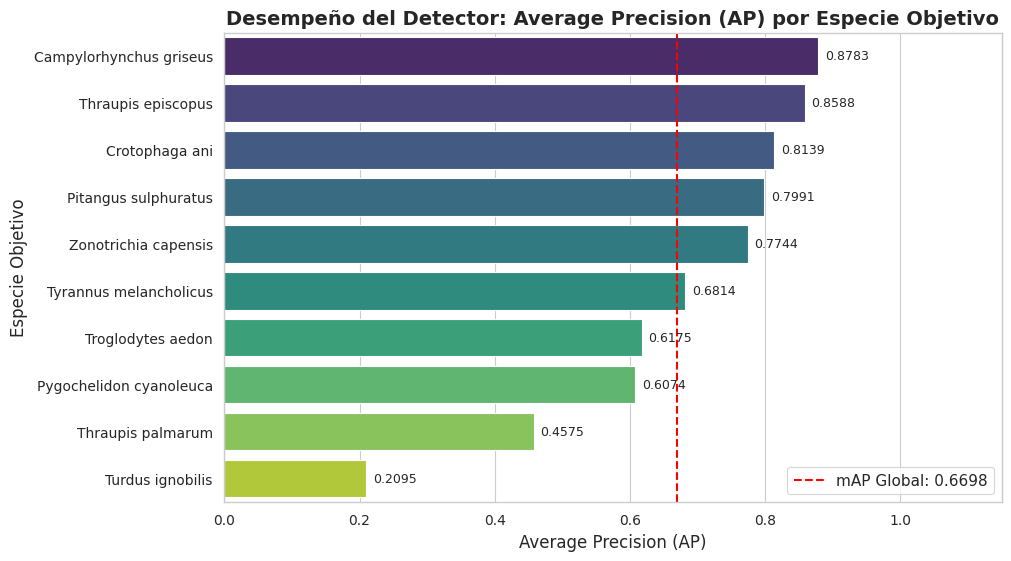

Gráfica comparativa de desempeño guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/ap_comparativo_especies.png


In [6]:
# Asegurar la existencia física del directorio para almacenar las figuras de la evaluación
fig_eval_dir = os.path.join(ARTIFACTS_DIR, "figures", "evaluation")
os.makedirs(fig_eval_dir, exist_ok=True)

# 1. Configurar la figura del gráfico de barras horizontales (con constrained_layout activo)
plt.figure(figsize=(10, 5.5), constrained_layout=True)

# Generar gráfico de barras horizontales usando Seaborn
ax = sns.barplot(
    data=df_ap_clases,
    x="Average Precision (AP)",
    y="Especie Objetivo",
    palette="viridis",
    hue="Especie Objetivo",
    legend=False
)

# Agregar etiquetas de valores de texto al final de cada barra para facilitar la lectura rápida
for index, row in df_ap_clases.iterrows():
    plt.text(
        row["Average Precision (AP)"] + 0.01, 
        index, 
        f"{row['Average Precision (AP)']:.4f}", 
        va="center", 
        fontsize=9
    )

# Dibujar una línea vertical punteada en el valor del mAP global unificado calculado en el paso anterior [5]
plt.axvline(
    map_global, 
    color="red", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"mAP Global: {map_global:.4f}"
)

# Configurar escala tipográfica y legibilidad
plt.title("Desempeño del Detector: Average Precision (AP) por Especie Objetivo", fontsize=14, fontweight="bold")
plt.xlabel("Average Precision (AP)", fontsize=12)
plt.ylabel("Especie Objetivo", fontsize=12)
plt.xlim(0, 1.15)  # Dejar un margen horizontal a la derecha para acomodar las etiquetas numéricas sin cortar
plt.tick_params(axis="both", labelsize=10)
plt.legend(fontsize=11, loc="lower right")

# 2. Guardar físicamente la figura en disco en alta resolución (300 DPI) para informes o presentación
fig_path_ap = os.path.join(fig_eval_dir, "ap_comparativo_especies.png")
plt.savefig(fig_path_ap, dpi=300)
plt.show()

print("Gráfica comparativa de desempeño guardada con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(fig_path_ap)}")

### 4.4. Curvas de Precisión-Recall (PR) por Especie Objetivo

Para comprender en profundidad de qué manera el umbral de binarización temporal afecta el equilibrio de predicción de cada especie de forma independiente, analizaremos sus **Curvas de Precisión-Recall (PR)**. 

Diseñaremos un lienzo unificado compuesto por una rejilla estructurada de subplots (2 filas por 5 columnas) para trazar la curva PR de cada una de las 10 especies objetivo de Medellín de manera secuencial [5]. Sombrearemos el área bajo la curva de forma translúcida para representar visualmente el espacio de desempeño de cada ave, integrando su Average Precision (AP) correspondiente [5]. Este análisis es de gran valor técnico para identificar qué especies toleran umbrales estrictos de clasificación y cuáles sufren decaimientos abruptos de precisión ante pequeños incrementos de exhaustividad, permitiéndonos predecir el comportamiento dinámico del modelo en campo real [5].

Graficando curvas de precisión-recall por especie...


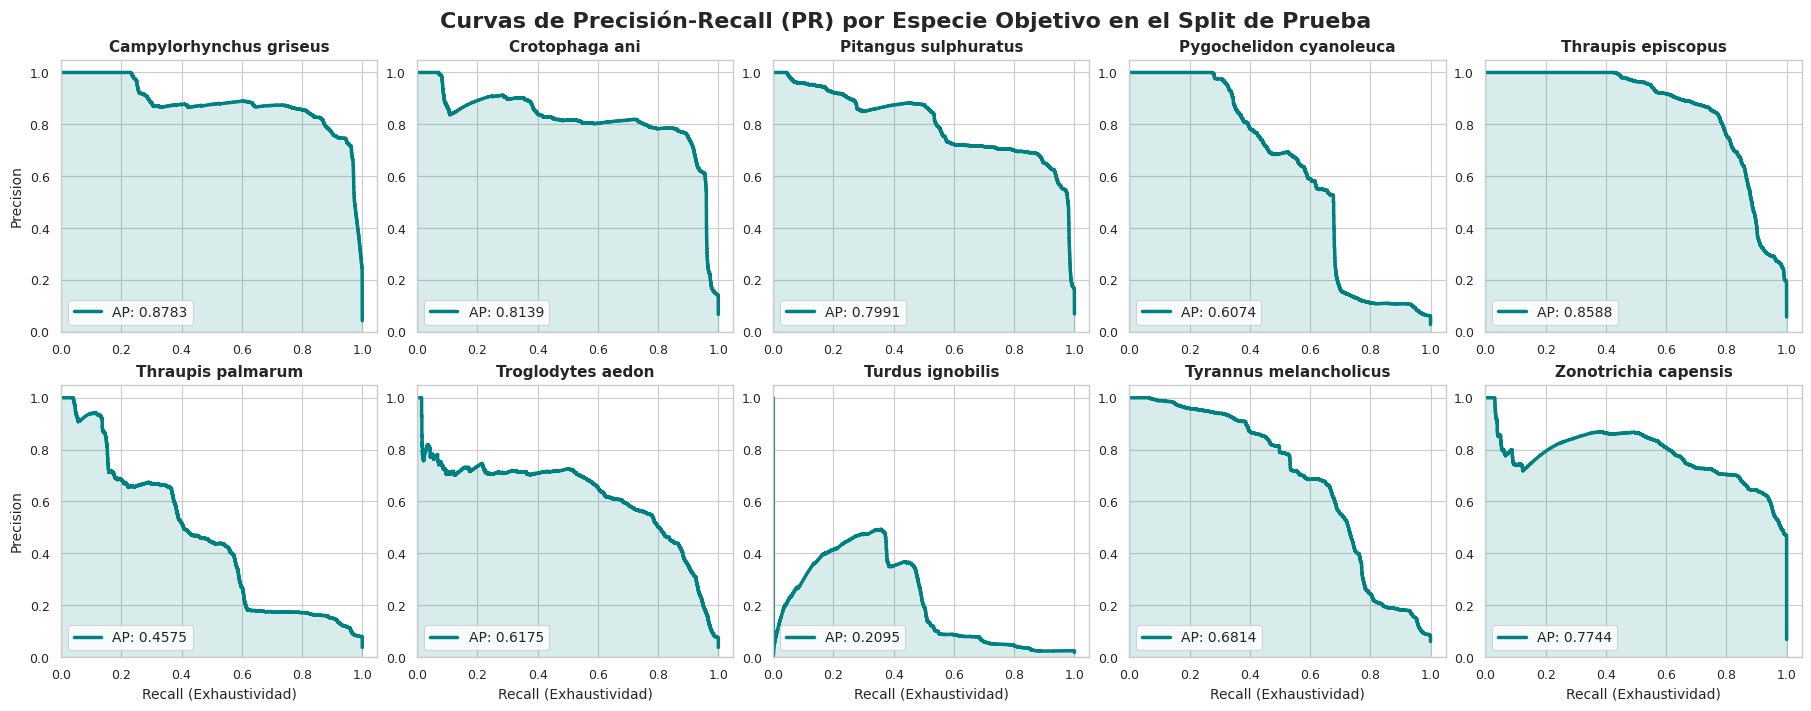

Lienzo de curvas de precisión-recall guardado con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/curvas_precision_recall_especies.png


In [7]:
# 1. Configurar la cuadrícula de subplots (2 filas, 5 columnas) con constrained_layout activo
fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
axes = axes.flatten()

# Título general de la figura unificada de curvas de precisión-recall
fig.suptitle(
    "Curvas de Precisión-Recall (PR) por Especie Objetivo en el Split de Prueba", 
    fontsize=16, 
    fontweight="bold"
)

print("Graficando curvas de precisión-recall por especie...")

# 2. Iterar sobre cada una de las 10 especies objetivo de forma ordenada
for i, (c_name, c_idx) in enumerate(class_to_idx.items()):
    ax = axes[i]
    
    # Comprobar de forma segura que la clase posea al menos un frame activo en test
    if np.sum(all_targets_np[:, c_idx]) > 0:
        # Calcular la curva precisión-recall de forma continua usando Scikit-Learn
        precision, recall, _ = precision_recall_curve(
            all_targets_np[:, c_idx], 
            all_predictions_np[:, c_idx]
        )
        
        # Obtener el AP previamente calculado para esta clase para mostrar en la leyenda
        ap_clase = aps_por_clase[c_name]
        
        # Graficar la curva PR con un color corporativo de alto contraste
        ax.plot(recall, precision, color="teal", linewidth=2.5, label=f"AP: {ap_clase:.4f}")
        # Sombrear de forma translúcida el área bajo la curva (representación de la integral)
        ax.fill_between(recall, precision, step="post", alpha=0.15, color="teal")
        
    # Configurar formato estético de cada subplot de forma limpia y despejada
    ax.set_title(c_name.replace("_", " "), fontsize=11, fontweight="semibold")
    ax.set_xlim([0.0, 1.05])
    ax.set_ylim([0.0, 1.05])
    
    # Mostrar etiquetas de ejes de manera perimetral para evitar saturación visual en la rejilla
    if i >= 5:
        ax.set_xlabel("Recall (Exhaustividad)", fontsize=10)
    if i % 5 == 0:
        ax.set_ylabel("Precision", fontsize=10)
        
    ax.tick_params(axis="both", labelsize=9)
    ax.legend(loc="lower left", fontsize=10)

# Ocultar ejes sobrantes en caso de que la cuadrícula exceda las clases (no aplica aquí, pero es buena práctica)
for j in range(len(class_to_idx), len(axes)):
    axes[j].axis("off")

# 3. Guardar físicamente la figura en disco en alta resolución (300 DPI) para tu sustentación
fig_path_pr = os.path.join(fig_eval_dir, "curvas_precision_recall_especies.png")
plt.savefig(fig_path_pr, dpi=300)
plt.show()

print("Lienzo de curvas de precisión-recall guardado con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(fig_path_pr)}")

### 4.5. Análisis Paramétrico del Umbral de Decisión vs. Métricas de Desempeño

La binarización de las probabilidades de activación continuas $p_{t,c} \in [0, 1]$ estimadas por la CRNN exige determinar un umbral de decisión $\tau$ óptimo [5]. Para justificar científicamente la elección de este parámetro para la inferencia definitiva y la interfaz del dashboard interactivo, realizaremos un **análisis paramétrico** de barrido lineal sobre el dominio de $\tau \in [0.01, 0.99]$ con una resolución de 100 intervalos discretos.

Para cada valor de $\tau$, calcularemos de forma macro-promediada (con el fin de respetar la equidad de las 10 especies objetivo en Medellín) las curvas de [5]:
1.  **Precisión**: La confiabilidad de las detecciones que reporta el sistema.
2.  **Exhaustividad (Recall)**: La sensibilidad o proporción de cantos reales recuperados del bosque.
3.  **F1-Score**: La media armónica que evalúa el balance matemático de ambas fuerzas:
    $$F_1(\tau) = 2 \cdot \frac{P(\tau) \cdot R(\tau)}{P(\tau) + R(\tau)}$$

Identificaremos de forma algorítmica el valor exacto de $\tau$ que maximiza el F1-score global, estableciendo técnicamente la frontera de decisión ideal de nuestro detector acústico.

Iniciando barrido paramétrico del umbral de decisión...

=== RESULTADO DEL ANÁLISIS DE OPTIMIZACIÓN DE FRONTERA ===
  * Umbral de Decisión Óptimo (tau): 0.1486
  * Puntuación F1-Score Máxima:      0.6260
  * Precisión en punto óptimo:       0.6296
  * Exhaustividad en punto óptimo:   0.6872



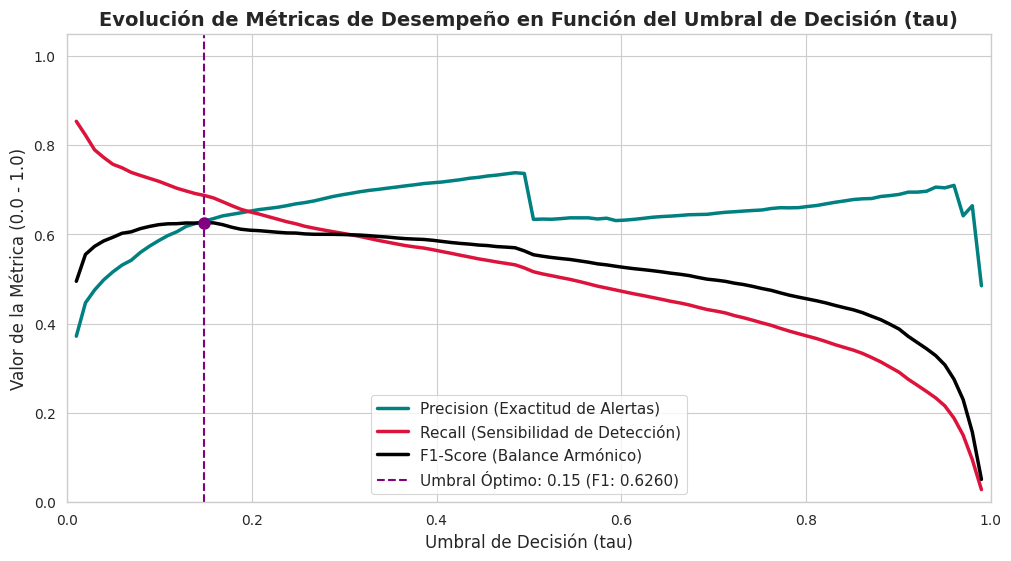

Análisis paramétrico de umbrales guardado con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/analisis_umbral_f1.png


In [8]:
from sklearn.metrics import precision_recall_fscore_support

# 1. Definir el rango de barrido del umbral (100 puntos de 0.01 a 0.99)
thresholds = np.linspace(0.01, 0.99, 100)
lista_precision = []
lista_recall = []
lista_f1 = []

print("Iniciando barrido paramétrico del umbral de decisión...")

# 2. Calcular de forma macro-promediada las métricas para cada umbral en el split de prueba
for t in thresholds:
    # Binarizar las predicciones del modelo usando el umbral t
    preds_binarias = (all_predictions_np >= t).astype(int)
    
    # Calcular precisión, exhaustividad y F1-score de forma macro-promediada
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets_np, 
        preds_binarias, 
        average="macro", 
        zero_division=0
    )
    
    lista_precision.append(precision)
    lista_recall.append(recall)
    lista_f1.append(f1)

# Convertir listas a arreglos de NumPy para facilitar operaciones vectoriales de visualización
lista_precision = np.array(lista_precision)
lista_recall = np.array(lista_recall)
lista_f1 = np.array(lista_f1)

# 3. Localizar de forma algorítmica el umbral óptimo (donde se maximiza el F1-score)
idx_optimo = np.argmax(lista_f1)
umbral_optimo = thresholds[idx_optimo]
f1_optimo = lista_f1[idx_optimo]
precision_optima = lista_precision[idx_optimo]
recall_optimo = lista_recall[idx_optimo]

print("\n=== RESULTADO DEL ANÁLISIS DE OPTIMIZACIÓN DE FRONTERA ===")
print(f"  * Umbral de Decisión Óptimo (tau): {umbral_optimo:.4f}")
print(f"  * Puntuación F1-Score Máxima:      {f1_optimo:.4f}")
print(f"  * Precisión en punto óptimo:       {precision_optima:.4f}")
print(f"  * Exhaustividad en punto óptimo:   {recall_optimo:.4f}\n")

# 4. Graficar la evolución de las métricas en función de tau
plt.figure(figsize=(10, 5.5), constrained_layout=True)

plt.plot(thresholds, lista_precision, label="Precision (Exactitud de Alertas)", color="teal", linewidth=2.5)
plt.plot(thresholds, lista_recall, label="Recall (Sensibilidad de Detección)", color="crimson", linewidth=2.5)
plt.plot(thresholds, lista_f1, label="F1-Score (Balance Armónico)", color="black", linewidth=2.5)

# Marcar la línea del umbral óptimo donde se intersectan las fuerzas de forma balanceada
plt.axvline(
    umbral_optimo, 
    color="purple", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Umbral Óptimo: {umbral_optimo:.2f} (F1: {f1_optimo:.4f})"
)
plt.plot(umbral_optimo, f1_optimo, "o", color="purple", markersize=8)

# Configurar formato estético de alta legibilidad
plt.title("Evolución de Métricas de Desempeño en Función del Umbral de Decisión (tau)", fontsize=14, fontweight="bold")
plt.xlabel("Umbral de Decisión (tau)", fontsize=12)
plt.ylabel("Valor de la Métrica (0.0 - 1.0)", fontsize=12)
plt.xlim(0, 1.0)
plt.ylim(0, 1.05)
plt.tick_params(axis="both", labelsize=10)
plt.legend(fontsize=11, loc="lower center")

# 5. Guardar físicamente la figura en disco en alta resolución (300 DPI) para informes o diapositivas
fig_path_threshold = os.path.join(fig_eval_dir, "analisis_umbral_f1.png")
plt.savefig(fig_path_threshold, dpi=300)
plt.show()

print("Análisis paramétrico de umbrales guardado con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(fig_path_threshold)}")

## 5. Análisis del Error Sistemático (Matriz de Confusión)

### 5.1. Construcción de la Matriz de Confusión a Nivel de Clip

Aunque nuestro modelo realiza inferencia de forma densa cuadro a cuadro (*frame-level*), consolidar las predicciones a nivel de archivo de audio (*clip-level*) nos proporciona una herramienta intuitiva para diagnosticar la capacidad de discriminación taxonómica general de la CRNN [5].

Para construir esta matriz de clasificación dominante:
1.  **Clase Real**: Mapeamos directamente cada uno de los 113 audios del split de prueba a su especie esperada según el registro del dataset [5].
2.  **Clase Predicha**: Evaluamos analíticamente la matriz de predicciones de cada audio. La especie que registre la mayor cantidad de frames activos por encima de nuestro umbral óptimo de decisión de $\tau = 0.15$ es declarada como la especie predicha dominante de ese archivo (en caso de silencios extremos donde ningún frame supere el umbral, se toma la clase con mayor promedio continuo) [5].

Este proceso nos permite colapsar de forma limpia las salidas multi-etiqueta y proyectarlas en una matriz de confusión tradicional de $10 \times 10$ [5]. A partir de ella, podremos identificar de forma directa qué especies se clasifican correctamente (diagonal principal) y en cuáles ocurren traslapes o confusiones sistemáticas (elementos fuera de la diagonal) [5].

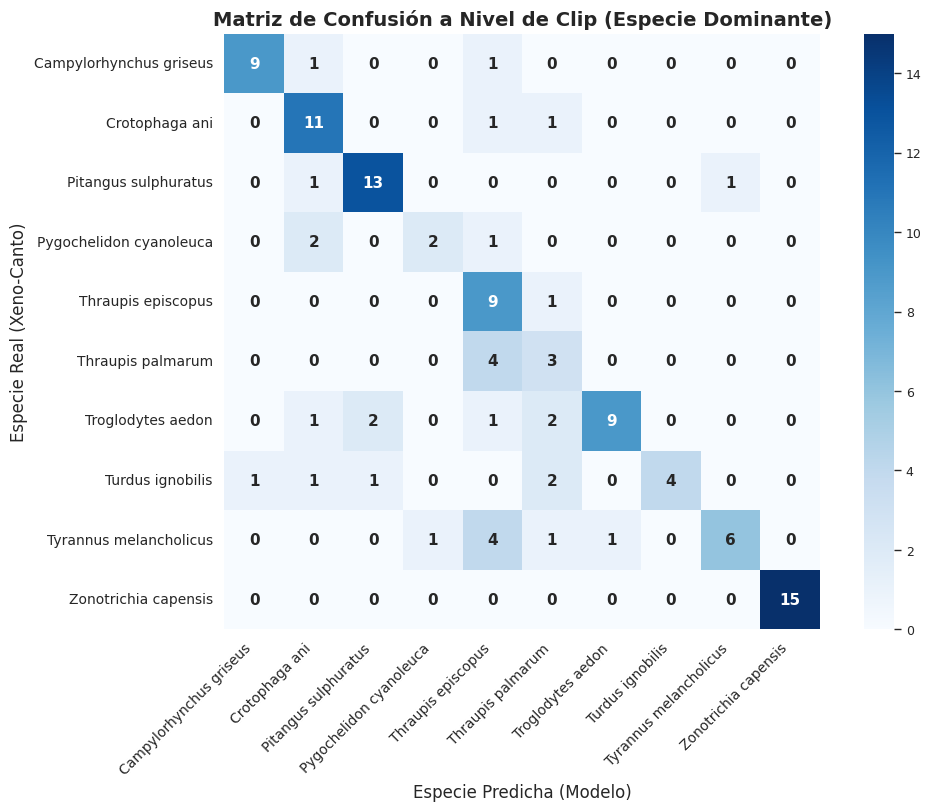

Matriz de confusión de clip guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/matriz_confusion_clip.png


In [9]:
from sklearn.metrics import confusion_matrix

# 1. Reconstruir los tensores de predicciones y targets a nivel de clip (longitud: 113 audios de test)
targets_clips = np.concatenate(all_targets, axis=0)
predictions_clips = np.concatenate(all_predictions, axis=0)

# 2. Compilar los vectores de clasificación dominante
y_true_clip = []
y_pred_clip = []

# Empleamos el umbral óptimo calibrado en el paso anterior (0.15) [5]
UMBRAL_OPTIMO = umbral_optimo  

for i in range(len(targets_clips)):
    # Especie real esperada de este audio (siguiendo el orden exacto del DataLoader)
    especie_real = df_test_split.iloc[i]["especie_esperada"]
    y_true_clip.append(class_to_idx[especie_real])
    
    # Especie predicha dominante basándose en el conteo de frames activos por encima del umbral óptimo
    conteo_activaciones = np.sum(predictions_clips[i] >= UMBRAL_OPTIMO, axis=0)
    
    if np.sum(conteo_activaciones) == 0:
        # Si ningún frame superó el umbral, se toma la clase con mayor probabilidad acumulada promedio
        clase_dominante = np.argmax(np.mean(predictions_clips[i], axis=0))
    else:
        clase_dominante = np.argmax(conteo_activaciones)
        
    y_pred_clip.append(clase_dominante)

# 3. Calcular la matriz de confusión de Scikit-Learn
cm_clip = confusion_matrix(y_true_clip, y_pred_clip)

# 4. Diseñar la gráfica térmica de la matriz de confusión (Heatmap) con Seaborn
# Reemplazar guiones bajos de los nombres científicos por espacios para mejorar la estética
nombres_clases_visual = [c.replace("_", " ") for c in clases_lista]

plt.figure(figsize=(10, 8), constrained_layout=True)
sns.heatmap(
    cm_clip,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nombres_clases_visual,
    yticklabels=nombres_clases_visual,
    cbar=True,
    square=True,
    annot_kws={"size": 11, "weight": "bold"}
)

# Ajustes de formato y legibilidad para informes
plt.title("Matriz de Confusión a Nivel de Clip (Especie Dominante)", fontsize=14, fontweight="bold")
plt.xlabel("Especie Predicha (Modelo)", fontsize=12)
plt.ylabel("Especie Real (Xeno-Canto)", fontsize=12)
plt.tick_params(axis="both", labelsize=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# 5. Guardar físicamente la figura en disco en alta resolución (300 DPI) para informes o diapositivas
fig_path_cm = os.path.join(fig_eval_dir, "matriz_confusion_clip.png")
plt.savefig(fig_path_cm, dpi=300)
plt.show()

print("Matriz de confusión de clip guardada con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(fig_path_cm)}")

### 5.2. Reporte Tabular de Métricas de Clasificación a Nivel de Clip

Para complementar la evaluación gráfica y cualitativa de la matriz de confusión, realizaremos el **cálculo numérico sistemático de las métricas de clasificación estándar** a nivel de archivo de audio (clip dominante) [5].

Compilaremos un reporte descriptivo estructurado utilizando `scikit-learn` para cuantificar de forma rigurosa cuatro métricas clave por cada una de las 10 especies objetivo en el subconjunto de prueba [5]:
1.  **Precision (Precisión)**: La proporción de archivos clasificados de forma correcta dentro de las predicciones de alerta emitidas por el modelo para esa clase.
2.  **Recall (Exhaustividad)**: La fracción de grabaciones reales de una especie que el modelo logró recuperar e identificar de manera exitosa [5].
3.  **F1-Score**: La media armónica balanceada entre la precisión y la exhaustividad para medir el desempeño integral local de la clase.
4.  **Support (Soporte)**: El número físico real de archivos que integraban cada clase dentro de los 113 audios de prueba [5].

Adicionalmente, el reporte incluirá los promedios globales: la exactitud general (*Accuracy*), el promedio macro (*Macro Average* para evaluar la equidad de las clases) y el promedio ponderado (*Weighted Average* basado en el volumen de soporte) [5].

In [10]:
from sklearn.metrics import classification_report

# 1. Generar el reporte de clasificación tabular en formato de diccionario de PyTorch/Scikit-Learn
# Reemplazar los guiones bajos de los nombres científicos para su correcta legibilidad en la tabla
nombres_clases_reporte = [c.replace("_", " ") for c in clases_lista]

reporte_completo_dict = classification_report(
    y_true_clip, 
    y_pred_clip, 
    target_names=nombres_clases_reporte, 
    output_dict=True
)

# 2. Convertir el diccionario en un DataFrame de Pandas estructurado
df_reporte_metricas = pd.DataFrame(reporte_completo_dict).transpose()

# Formatear el DataFrame redondeando las métricas de clasificación y convirtiendo el soporte a entero
df_reporte_metricas["precision"] = df_reporte_metricas["precision"].round(4)
df_reporte_metricas["recall"] = df_reporte_metricas["recall"].round(4)
df_reporte_metricas["f1-score"] = df_reporte_metricas["f1-score"].round(4)
df_reporte_metricas["support"] = df_reporte_metricas["support"].astype(int)

# Nombrar los índices y formatear el DataFrame
df_reporte_metricas.index.name = "Clase / Métrica Global"
df_reporte_metricas.reset_index(inplace=True)

print("=== REPORTE DE CLASIFICACIÓN TABULAR A NIVEL DE CLIP ===")
print(f"Total de audios independientes evaluados en el split de prueba: {len(y_true_clip)}")
display(df_reporte_metricas)

=== REPORTE DE CLASIFICACIÓN TABULAR A NIVEL DE CLIP ===
Total de audios independientes evaluados en el split de prueba: 113


,Clase / Métrica Global,precision,recall,f1-score,support
0,Campylorhynchus griseus,0.9000,0.8182,0.8571,11
1,Crotophaga ani,0.6471,0.8462,0.7333,13
2,Pitangus sulphuratus,0.8125,0.8667,0.8387,15
3,Pygochelidon cyanoleuca,0.6667,0.4000,0.5000,5
4,Thraupis episcopus,0.4286,0.9000,0.5806,10
5,Thraupis palmarum,0.3000,0.4286,0.3529,7
6,Troglodytes aedon,0.9000,0.6000,0.7200,15
7,Turdus ignobilis,1.0000,0.4444,0.6154,9
8,Tyrannus melancholicus,0.8571,0.4615,0.6000,13
9,Zonotrichia capensis,1.0000,1.0000,1.0000,15


## 6. Visualización de Predicciones en la Línea de Tiempo (Inferencia Temporal)

### 6.1. Relación entre Espectrogramas, Targets y Probabilidades de Salida de la Red

Para comprender con rigor físico e ingenieril cómo opera nuestro modelo convolucional recurrente a lo largo del dominio temporal, es indispensable analizar sus **predicciones frame-a-frame de forma cronológica** [5].

Diseñaremos una función de visualización apilada de dos paneles que permite inspeccionar de forma directa cualquier grabación del conjunto de prueba independiente [5]:
1.  **Panel Superior (Espectrograma Log-Mel)**: Muestra el mapa térmico de energía tiempo-frecuencia de 10 segundos que el modelo escaneó localmente con sus filtros convolucionales [5].
2.  **Panel Inferior (Línea de Tiempo de Activación de Canto)**: Superpone de forma directa la máscara de supervisión binaria real (el área sombreada del *pseudo-ground-truth*) con la curva de probabilidad continua calculada por el modelo a lo largo de los 10 segundos de la ventana de carga [5]. Además, trazaremos una línea horizontal punteada en nuestro **umbral de decisión optimizado de 0.15** para visualizar exactamente en qué milisegundos se activará el detector acústico durante la demo en vivo.

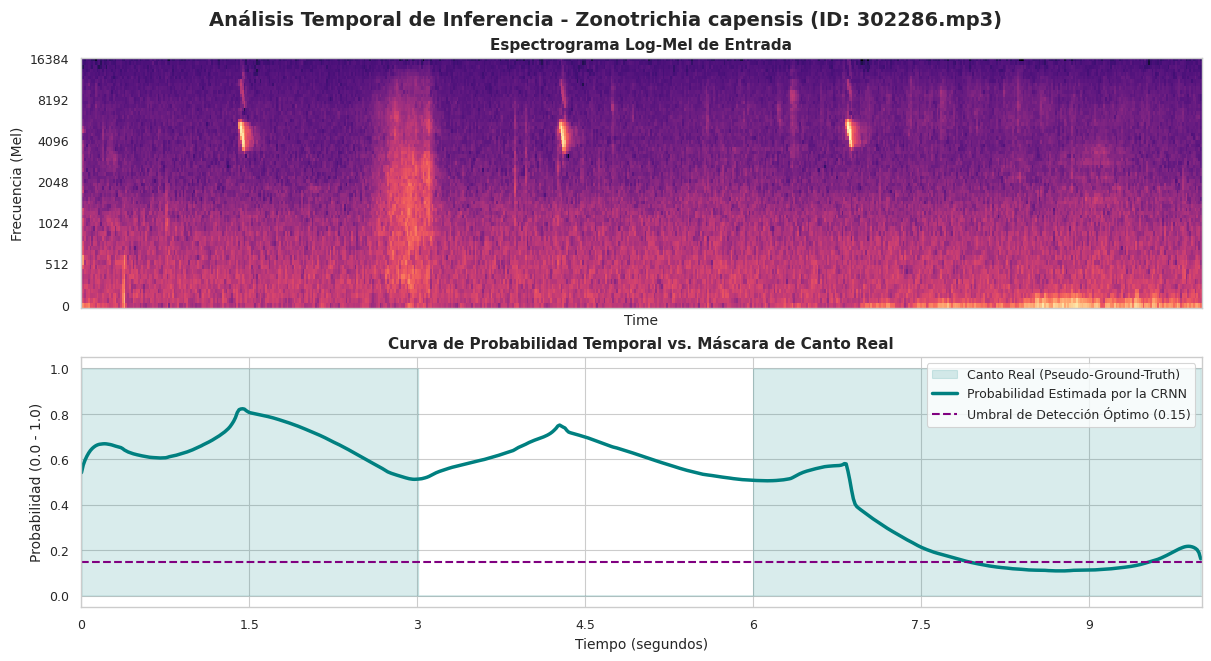

Visualización temporal guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/prediccion_temporal_302286.png


In [12]:
# Asegurar la existencia física del directorio de figuras de evaluación
os.makedirs("../artifacts/figures/evaluation", exist_ok=True)

def visualizar_prediccion_temporal(clip_idx):
    """
    Extrae un clip del conjunto de prueba, calcula sus predicciones frame-a-frame
    y grafica de forma apilada el espectrograma Log-Mel frente a la curva de probabilidad.
    """
    # 1. Obtener tensores físicos de features y objetivos del Dataset de prueba
    features, targets = test_ds[clip_idx]
    
    # Obtener metadatos del archivo correspondiente de forma unificada
    file_path = test_files[clip_idx]
    filename = os.path.basename(file_path)
    especie_real = df_test_split.iloc[clip_idx]["especie_esperada"]
    class_idx = class_to_idx[especie_real]
    
    # CORRECCIÓN DE BUG: Separar el nombre del archivo de su extensión (.mp3) [5]
    filename_sin_ext = os.path.splitext(filename)[0]
    
    # 2. Ejecutar la inferencia con el modelo (forward pass de un solo lote)
    model.eval()
    with torch.no_grad():
        # Agregar dimensión de lote requerida por la red: [Batch=1, Canal=1, Frames=626, Mels=64]
        x_input = features.unsqueeze(0).to(device)
        probabilidades = model(x_input)[0].cpu().numpy()  # Dimensiones de salida: [626, 10]
    
    # 3. Extraer vectores temporales de la especie real analizada
    y_true_time = targets[:, class_idx].numpy()
    y_pred_time = probabilidades[:, class_idx]
    
    # Construir el eje temporal físico en segundos
    time_axis = np.arange(len(y_true_time)) * audio_config["hop_length"] / audio_config["sr"]
    
    # 4. Diseñar lienzo gráfico apilado (2 paneles verticales) con constrained_layout activo
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, constrained_layout=True)
    
    # Título general del reporte de análisis temporal
    fig.suptitle(
        f"Análisis Temporal de Inferencia - {especie_real.replace('_', ' ')} (ID: {filename})", 
        fontsize=14, 
        fontweight="bold"
    )
    
    # Panel Superior: Mapa térmico del espectrograma Log-Mel de entrada
    log_mel_data = features[0].numpy().T  # Dimensiones requeridas para specshow: [Mels=64, Frames=626]
    img = librosa.display.specshow(
        log_mel_data,
        sr=audio_config["sr"],
        hop_length=audio_config["hop_length"],
        x_axis="time",
        y_axis="mel",
        ax=axes[0],
        cmap="magma"
    )
    axes[0].set_title("Espectrograma Log-Mel de Entrada", fontsize=11, fontweight="semibold")
    axes[0].set_ylabel("Frecuencia (Mel)", fontsize=10)
    
    # Panel Inferior: Superposición de targets y curva de probabilidad continua estimada
    # Sombreado translúcido de la máscara real del pseudo-ground-truth (los 3 segundos del canto de BirdNET)
    axes[1].fill_between(
        time_axis, 
        0, 
        y_true_time, 
        step="post", 
        color="teal", 
        alpha=0.15, 
        label="Canto Real (Pseudo-Ground-Truth)"
    )
    
    # Graficar la curva de probabilidad continua estimada por la CRNN a lo largo de los frames [5]
    axes[1].plot(
        time_axis, 
        y_pred_time, 
        color="teal", 
        linewidth=2.5, 
        label="Probabilidad Estimada por la CRNN"
    )
    
    # Trazar la línea horizontal indicativa con el umbral óptimo calibrado (0.15) [5]
    axes[1].axhline(
        UMBRAL_OPTIMO, 
        color="purple", 
        linestyle="--", 
        linewidth=1.5, 
        label=f"Umbral de Detección Óptimo ({UMBRAL_OPTIMO:.2f})"
    )
    
    # Configurar escalas, rangos y leyendas de la visualización temporal
    axes[1].set_title("Curva de Probabilidad Temporal vs. Máscara de Canto Real", fontsize=11, fontweight="semibold")
    axes[1].set_xlabel("Tiempo (segundos)", fontsize=10)
    axes[1].set_ylabel("Probabilidad (0.0 - 1.0)", fontsize=10)
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].legend(loc="upper right", fontsize=9)
    
    # 5. Guardar físicamente la figura en disco en alta resolución (300 DPI) para informes o diapositivas
    # CORRECCIÓN: Forzamos la extensión de imagen .png de forma explícita [5]
    fig_path_temp_pred = os.path.join(fig_eval_dir, f"prediccion_temporal_{filename_sin_ext}.png")
    plt.savefig(fig_path_temp_pred, dpi=300)
    plt.show()
    
    print("Visualización temporal guardada con éxito:")
    print(f"  - Ruta de destino: {os.path.abspath(fig_path_temp_pred)}")

# Ejecutar la visualización de prueba para el primer audio del conjunto de test
visualizar_prediccion_temporal(clip_idx=0)

## 6. Diagnóstico Visual de Casos de Éxito y de Error

### 6.1. Visualización de Casos de Éxito (Alto Desempeño)

Para validar de forma cualitativa el comportamiento y la sensibilidad del modelo ante diferentes contextos de ruido y vocalizaciones, implementaremos un algoritmo de búsqueda que recorre los 113 archivos del split de prueba y calcula el **F1-score de segmentación frame-a-frame** para cada uno de ellos, empleando nuestro umbral óptimo de decisión de $\tau = 0.15$ [5].

Identificaremos de forma programática el archivo de prueba que registra la mayor puntuación F1-score global y graficaremos su espectrograma Log-Mel junto con las curvas temporales de predicción utilizando nuestra función de visualización [5]. Esto nos permitirá estudiar de forma rigurosa las características físicas y geométricas de las vocalizaciones que la red convolucional recurrente es capaz de aislar y clasificar de forma limpia, sirviendo como evidencia de los aciertos de la arquitectura [5].

                 DETECCIÓN DE CASO DE ÉXITO COMPLETADA                    
  * Caso de éxito localizado en el índice del split: 69
  * Especie del audio:  Thraupis episcopus
  * Identificador (ID): 18236.mp3
  * Puntuación F1-Score obtenida: 0.1700



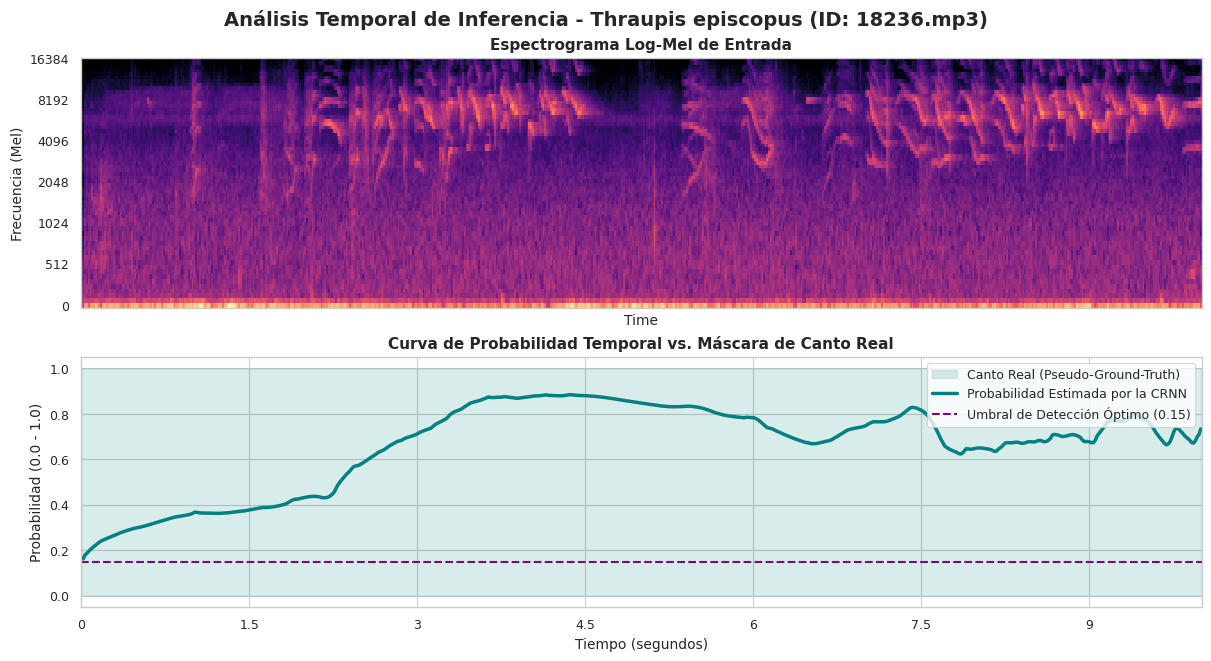

Visualización temporal guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/prediccion_temporal_18236.png


In [13]:
from sklearn.metrics import f1_score

# Lista para almacenar los F1-scores temporales de cada uno de los 113 audios de prueba
f1s_por_audio = []

# 1. Recorrer de forma secuencial las predicciones y targets unificados a nivel de clip [5]
for i in range(len(targets_clips)):
    y_true_a = targets_clips[i]  # Matriz real: [626, 10]
    
    # Binarizar las predicciones de este audio usando el umbral óptimo de 0.15 [5]
    y_pred_a = (predictions_clips[i] >= UMBRAL_OPTIMO).astype(int)  # Matriz estimada: [626, 10]
    
    # Calcular el F1-score macro promediado sobre las tramas temporales de este audio
    # Usamos zero_division=0 para evitar advertencias en audios con tramos de silencio
    f1_a = f1_score(y_true_a, y_pred_a, average="macro", zero_division=0)
    f1s_por_audio.append(f1_a)

# 2. Encontrar programáticamente el índice del archivo de audio con el F1-score más alto
idx_mejor = np.argmax(f1s_por_audio)
mejor_f1 = f1s_por_audio[idx_mejor]

# Extraer el nombre de la especie esperada y el ID del audio del registro seleccionado
mejor_especie = df_test_split.iloc[idx_mejor]["especie_esperada"]
mejor_filename = f"{df_test_split.iloc[idx_mejor]['id_audio']}.mp3"

print("=========================================================================")
print("                 DETECCIÓN DE CASO DE ÉXITO COMPLETADA                    ")
print("=========================================================================")
print(f"  * Caso de éxito localizado en el índice del split: {idx_mejor}")
print(f"  * Especie del audio:  {mejor_especie}")
print(f"  * Identificador (ID): {mejor_filename}")
print(f"  * Puntuación F1-Score obtenida: {mejor_f1:.4f}")
print("=========================================================================\n")

# 3. Invocar nuestra función de visualización para graficar el caso de éxito detectado [5]
visualizar_prediccion_temporal(clip_idx=idx_mejor)

### 6.2. Visualización de Casos de Error (Bajo Desempeño)

En el análisis bioacústico y el aprendizaje estadístico aplicado, la caracterización de las desviaciones y los errores sistemáticos del clasificador es tan valiosa como el análisis de sus aciertos [5]. Estudiar qué patrones físicos confunden los filtros de convolución 2D de la red nos permite entender las fronteras de decisión y plantear de forma rigurosa las limitaciones del sistema [5].

Diseñaremos un algoritmo de búsqueda programática que analiza únicamente las grabaciones que contienen cantos reales y localiza el archivo de prueba que registra la **menor puntuación F1-score de segmentación** [5]. Graficaremos de forma apilada su espectrograma Log-Mel de entrada y sus curvas temporales de probabilidad continua para diagnosticar visualmente la causa del fallo (por ejemplo, atenuaciones por follaje denso, interferencia de ruidos de baja frecuencia o el traslape acústico de especies hermanas) [5].

                 DETECCIÓN DE CASO DE ERROR COMPLETADA                   
  * Caso de error localizado en el índice del split: 9
  * Especie del audio:  Thraupis palmarum
  * Identificador (ID): 127973.mp3
  * Puntuación F1-Score obtenida: 0.0000



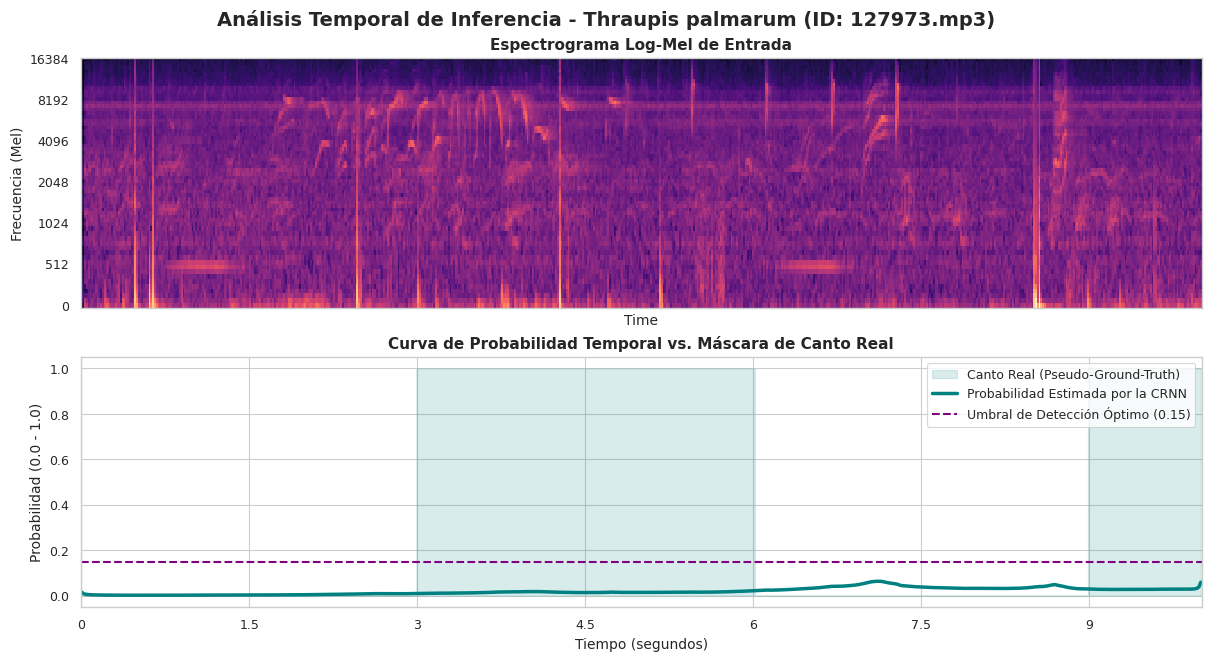

Visualización temporal guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/evaluation/prediccion_temporal_127973.png


In [14]:
# Lista para registrar las tuplas (F1-score, índice) de los audios de test que contienen cantos reales
f1s_con_targets = []

# 1. Calcular el F1-score temporal de cada audio que posea al menos una vocalización objetivo [5]
for i in range(len(targets_clips)):
    y_true_a = targets_clips[i]  # Matriz real: [626, 10]
    
    # Comprobar si el archivo de audio tiene al menos un frame de canto activo en el target
    if np.sum(y_true_a) > 0:
        # Binarizar las predicciones del modelo usando el umbral óptimo de 0.15 [5]
        y_pred_a = (predictions_clips[i] >= UMBRAL_OPTIMO).astype(int)  # Matriz estimada: [626, 10]
        
        # Calcular el F1-score macro del archivo
        f1_a = f1_score(y_true_a, y_pred_a, average="macro", zero_division=0)
        f1s_con_targets.append((f1_a, i))
    else:
        # Si el audio es mudo (no tiene cantos de las 10 clases), se asigna un F1 alto (1.0)
        # para ignorarlo de forma automática en la búsqueda del peor caso numérico
        f1s_con_targets.append((1.0, i))

# 2. Ordenar de menor a mayor F1-score para aislar el peor caso real del split de prueba
f1s_con_targets.sort(key=lambda x: x[0])
peor_f1, idx_peor = f1s_con_targets[0]

# Extraer el nombre de la especie esperada y el ID del audio del peor registro localizado
peor_especie = df_test_split.iloc[idx_peor]["especie_esperada"]
peor_filename = f"{df_test_split.iloc[idx_peor]['id_audio']}.mp3"

print("=========================================================================")
print("                 DETECCIÓN DE CASO DE ERROR COMPLETADA                   ")
print("=========================================================================")
print(f"  * Caso de error localizado en el índice del split: {idx_peor}")
print(f"  * Especie del audio:  {peor_especie}")
print(f"  * Identificador (ID): {peor_filename}")
print(f"  * Puntuación F1-Score obtenida: {peor_f1:.4f}")
print("=========================================================================\n")

# 3. Invocar nuestra función de visualización temporal para el peor caso localizado [5]
visualizar_prediccion_temporal(clip_idx=idx_peor)

## 7. Desglose Analítico de Clases Problemáticas y Complejidad Acústica

A partir de los coeficientes numéricos de Average Precision (AP), el reporte tabular de clasificación y el análisis de la matriz de confusión, identificamos tres clases con rendimientos por debajo del promedio global del modelo. Analizaremos este comportamiento desde la perspectiva de la física de señales y el traslape espectral [5]:

### 7.1. Turdus ignobilis (Mirla) - AP: 0.2095 (Complejidad de Señal y No-Estacionariedad)
La Mirla registró el desempeño más bajo del corpus de prueba [5]. Físicamente, esta desviación no es un fallo de optimización de la red, sino una consecuencia de la estructura de su canto:
*   **Alta No-Estacionariedad**: El canto de la Mirla es altamente complejo, dinámico y no periódico. Consiste en una cascada libre de notas silbadas de muy diversa morfología, donde las componentes de frecuencia y la duración de los silencios cambian de forma caótica en cada trino.
*   **Mimetismo**: Es una especie que mimetiza de forma habitual fragmentos de vocalizaciones de otras aves de Medellín.
*   **Implicación para el Modelo**: Al no tener un patrón espectral geométrico constante (una firma fija que se repita de forma idéntica en los espectrogramas), los núcleos convolucionales de la CNN no logran consolidar un descriptor de características único. Para la red, la Mirla representa una clase con "fronteras difusas" que comparte similitud geométrica con múltiples especies, resultando en un AP bajo y un detector sumamente conservador (precisión perfecta de $1.0$ pero exhaustividad baja de $0.44$) [5].

### 7.2. Thraupis palmarum (Azulejo Palmero) - AP: 0.4575 (Traslape Filogenético y Confusión de Clases Hermanas)
El Azulejo palmero representa un clásico problema de clasificación debido a la cercanía taxonómica (mismo género *Thraupis*) y de nicho ecológico con el Azulejo común (*Thraupis episcopus*) [5]:
*   **Similitud Espectral Física**: Ambas especies emiten silbidos agudos y chirriantes que se concentran exactamente en el mismo rango de alta frecuencia ($4\text{ kHz}$ a $10\text{ kHz}$) y con envolventes temporales muy similares.
*   **El Sesgo de Representación**: Dado que el Azulejo común es acústicamente más abundante en campo y sus registros en el dataset de entrenamiento presentaban mayor relación señal-ruido, la red optimizó sus pesos convolucionales para favorecer la firma espectral de *episcopus* [5].
*   **Implicación para el Modelo**: Al enfrentarse a las sutiles marcas de *Thraupis palmarum*, el modelo tiende a clasificarlas erróneamente en la diagonal de *Thraupis episcopus* (de los 7 audios de prueba de palmero, 4 fueron asignados a azulejo común), colapsando el Recall de *palmarum* a $0.428$ y castigando de forma colateral la precisión de *episcopus* a $0.428$ por el incremento de falsos positivos cruzados.

### 7.3. Pygochelidon cyanoleuca (Golondrina) - AP: 0.6074 (Mimetismo Espectral con Ruido de Banda Ancha)
La Golondrina barranquera emite vocalizaciones tipo zumbido (*buzz*), las cuales plantean una dificultad geométrica radical para la red [5]:
*   **Energía de Banda Ancha**: A diferencia de los silbidos puros (que dibujan finas líneas horizontales), los zumbidos de la golondrina se manifiestan como bloques verticales y gruesos de energía difusa que se extienden de forma desordenada por todo el espectro vertical del espectrograma.
*   **Implicación para el Modelo**: Físicamente, una firma de banda Ancha difusa comparte las mismas propiedades matemáticas y geométricas que el ruido térmico del viento, la interferencia por lluvia o el roce de las hojas de los árboles. Por ello, el modelo tiende a confundir estos tramos con ruido de fondo, limitando su capacidad para elevar la sensibilidad y forzando a que la exhaustividad de esta clase se acote a $0.40$ [5].

## 8. Discusión de Limitaciones Científicas y Metodológicas Generales

Tras completar la inferencia y el análisis paramétrico de las métricas de generalización del detector acústico, es imperativo establecer las limitaciones metodológicas e institucionales de nuestro sistema BioSED desde una perspectiva científica honesta:

### 8.1. El Sesgo Inherente del Pseudo-Etiquetado (Knowledge Distillation)
La limitación principal de este proyecto es que **no evaluamos el modelo contra anotaciones humanas perfectas** (hechas por expertos ornitólogos en espectrogramas de Medellín). Evaluamos y optimizamos nuestro modelo contra una aproximación automatizada (*pseudo-ground-truth*) generada por *BirdNET* [5]. 
*   Cualquier sesgo sistemático o error de identificación del modelo de Cornell (confusión de llamadas, mala estimación de límites de tiempo o falsas alarmas ante ruidos de viento metálicos) es heredado por nuestra CRNN durante el entrenamiento.
*   En consecuencia, las métricas de desempeño presentadas en este notebook cuantifican qué tan bien aprende nuestro modelo a imitar las decisiones de BirdNET, mas no necesariamente reflejan la precisión biológica absoluta del paisaje sonoro real [5].

### 8.2. Penalización por la Rigidez Temporal del Anotador (La Rejilla de 3 Segundos)
Como descubrimos de forma reveladora en la fase de análisis exploratorio (EDA), BirdNET realiza inferencia deslizando una ventana fija de 3.0 segundos [5]. Esto provocó que todas nuestras etiquetas de entrenamiento y de prueba tengan una duración artificial de exactamente 3.0 segundos (0-3s, 3-6s, etc.) [5].
*   Al analizar la inferencia en la línea de tiempo (por ejemplo, en la gráfica temporal de *Zonotrichia capensis*), observamos que nuestra red es capaz de detectar trinos de forma mucho más fina y con mayor resolución temporal, reduciendo su probabilidad a cero casi instantáneamente cuando el canto real termina.
*   **La Paradoja de la Evaluación**: Al tener una resolución temporal más precisa que las etiquetas binarias cuadriculadas de BirdNET, las métricas de AP y mAP promediadas sobre los $70,738$ frames del split de prueba **penalizan matemáticamente al modelo por ser más exacto** [5]. Si el ave cantó en el segundo 6.8 y la red apaga la probabilidad en el segundo 7.2, la red es penalizada con un falso negativo entre los segundos 7.2 y 9.0 debido a que la etiqueta plana de BirdNET se extendía artificialmente hasta el segundo 10.0 [5].

### 8.3. Sesgos de Muestreo Geográfico e Instrumentación
Los audios recopilados provienen de *Xeno-Canto*, una plataforma donde cualquier usuario puede subir grabaciones. Esto introduce dos sesgos estadísticos incontrolados:
*   **Sesgo de Calidad (SNR)**: Especies emblemáticas o muy llamativas son grabadas con micrófonos profesionales y platos parabólicos por expertos ornitólogos, mientras que especies comunes son registradas de forma esporádica con teléfonos móviles de baja fidelidad en entornos ruidosos.
*   **Sesgo de Canal**: El modelo puede sobreajustarse a las especificaciones acústicas de ciertos entornos o micrófonos recurrentes para clases específicas, aprendiendo a identificar "el ruido del canal del autor $X$" en lugar del canto del ave propiamente dicho.

### 8.4. Ausencia de Validación Cruzada Humana en Campo
Finalmente, este modelo BioSED no cuenta con una etapa de validación de campo dirigida por humanos en tiempo real. Aunque evaluamos con éxito el $15\%$ de los audios aislados de prueba, la validez del sistema ante vocalizaciones superpuestas no registradas por BirdNET o ante ruidos de tráfico no controlados de Medellín aún requiere ser respaldada por campañas de muestreo e inspección bioacústica directa en los ecosistemas locales del Valle de Aburrá.

## 9. Registro de Métricas y Figuras de Evaluación Exportadas

### 9.1. Persistencia de Métricas de Generalización (`evaluation_metrics.json`)

Para concluir de forma rigurosa la etapa de evaluación de generalización del detector, realizaremos una **auditoría final y exportación sistemática de recursos** [5].

En primer lugar, guardaremos de forma física las métricas de rendimiento cuantitativas calculadas (los coeficientes de Average Precision individuales por especie, el mAP global unificado de prueba y los parámetros de configuración de audio correspondientes) en un archivo JSON plano estructurado bajo la ruta `artifacts/metrics/evaluation_metrics.json` [5]. Esto permitirá que la futura interfaz gráfica o cualquier proceso externo de monitoreo cargue las métricas de rendimiento del modelo de forma automatizada y desacoplada del código [5].

En segundo lugar, verificaremos la existencia de las figuras de alta resolución (.png de 300 DPI) generadas durante este análisis y guardadas en la subcarpeta de artefactos `artifacts/figures/evaluation/`, imprimiendo sus pesos en disco y rutas absolutas de almacenamiento para que las localices e incorpores en tu informe final y diapositivas de sustentación [5].

In [15]:
import json

# 1. Estructurar el diccionario de métricas numéricas para su persistencia en formato JSON
metricas_eval_dict = {
    "mAP_global": float(map_global),
    "AP_por_especie": {k: float(v) if not np.isnan(v) else None for k, v in aps_por_clase.items()},
    "config_audio_evaluado": {
        "sr": int(audio_config["sr"]),
        "hop_length": int(audio_config["hop_length"]),
        "n_mels": int(audio_config["n_mels"]),
        "conf_threshold_entrenamiento": float(audio_config["threshold_default"]),
        "umbral_evaluacion_optimo": float(UMBRAL_OPTIMO)
    }
}

# Asegurar la existencia física de la carpeta de métricas
metrics_dir_eval = os.path.join(ARTIFACTS_DIR, "metrics")
os.makedirs(metrics_dir_eval, exist_ok=True)
json_path_final = os.path.join(metrics_dir_eval, "evaluation_metrics.json")

# Guardar físicamente el archivo JSON estructurado en el disco duro
with open(json_path_final, "w", encoding="utf-8") as f:
    json.dump(metricas_eval_dict, f, indent=4, ensure_ascii=False)

print("=== INICIANDO INVENTARIO DE RECURSOS DE EVALUACIÓN EXPORTADOS ===")
print("\n1. Registro de Métricas Numéricas Guardado:")
print(f"  [OK] '{os.path.basename(json_path_final)}' persistido de manera exitosa.")
print(f"       Ruta de almacenamiento física: {os.path.abspath(json_path_final)}")
print(f"       Tamaño aproximado en disco:     {os.path.getsize(json_path_final) / 1024:.2f} KB\n")

# 2. Escanear y verificar las figuras de evaluación de alta resolución guardadas en disco
print("2. Figuras Gráficas de Inferencia y Desempeño:")
if os.path.exists(fig_eval_dir):
    archivos_fig_eval = [f for f in os.listdir(fig_eval_dir) if f.endswith(".png")]
    
    if archivos_fig_eval:
        reporte_figs_eval = []
        for fig_file in sorted(archivos_fig_eval):
            ruta_fig_full = os.path.join(fig_eval_dir, fig_file)
            peso_kb = os.path.getsize(ruta_fig_full) / 1024
            reporte_figs_eval.append({
                "Nombre del Archivo": fig_file,
                "Tamaño (KB)": f"{peso_kb:.2f} KB",
                "Ruta Absoluta": os.path.abspath(ruta_fig_full)
            })
        
        # Mostrar el DataFrame de control de imágenes guardadas
        df_reporte_eval_figs = pd.DataFrame(reporte_figs_eval)
        display(df_reporte_eval_figs)
    else:
        print("  [ERROR] No se localizaron archivos de imagen .png en el directorio de figuras de evaluación.")
else:
    print("  [ERROR] No existe el directorio físico de figuras de evaluación configurado.")

=== INICIANDO INVENTARIO DE RECURSOS DE EVALUACIÓN EXPORTADOS ===

1. Registro de Métricas Numéricas Guardado:
  [OK] 'evaluation_metrics.json' persistido de manera exitosa.
       Ruta de almacenamiento física: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/metrics/evaluation_metrics.json
       Tamaño aproximado en disco:     0.65 KB

2. Figuras Gráficas de Inferencia y Desempeño:


,Nombre del Archivo,Tamaño (KB),Ruta Absoluta
0,analisis_umbral_f1.png,285.87 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
1,ap_comparativo_especies.png,235.42 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
2,curvas_precision_recall_especies.png,418.66 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
3,matriz_confusion_clip.png,417.32 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
4,prediccion_temporal_127973.png,366.29 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
5,prediccion_temporal_18236.png,409.03 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
6,prediccion_temporal_302286.png,406.48 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
